## SAM index code

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
import numpy as np
from cmocean import cm
import cartopy as cp
import cartopy.crs as ccrs
import netCDF4 as nc
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
import cartopy.feature as cfeature
from importlib import reload
import matplotlib.path as mpath
import glob
import pickle
import pandas as pd
import seawater
import time
import coldic as cd
reload(cd)

<module 'coldic' from '/gpfs/scratch/mep22dku/windEval/plottingCode/coldic.py'>

## visualize SAM ts

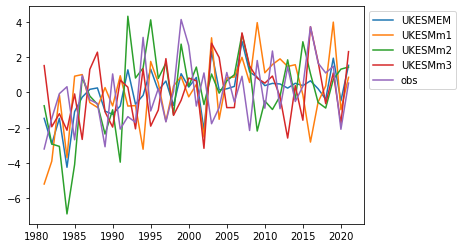

In [3]:
prods = ['UKESMEM','UKESMm1','UKESMm2','UKESMm3','obs']
# prods = ['UKESM']

plt.figure

for prod in prods:
    
    #if prod == 'UKESM': prod1 = 'UKESMEM'
    #else: prod1 = prod
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    
    wmn = w.resample(time='Y').mean()
    
    plt.plot(wmn.time,wmn.SAM, label = prod)
    #plt.plot(w.time,w.SAM, color = cd.prod[prod]['col'], label = cd.prod[prod]['fnam'], linewidth = 0.5)

plt.legend(bbox_to_anchor = [1, 1])
    

## trends fxn

In [4]:

import pymannkendall as mk
from scipy import stats

def give_trends(ts_y):

    ts_x = np.arange(0,len(ts_y))
    trend, h, mk_p, z, Tau, s, var_s, mk_slope, intercept = mk.original_test(ts_y)
    lin_slope, intercept, r_value, lin_p, std_err = stats.linregress(ts_x,ts_y)
    
    return mk_slope, mk_p, lin_slope, lin_p


## extract trends and significances for SAM ts

In [5]:
dss = ['ERA5','NCEP-NCAR','MERRA','JRA','UKESMEM','UKESMm1','UKESMm2','UKESMm3',\
       'UKESMEM-NO','UKESM-NOm1','UKESM-NOm2','UKESM-NOm3','obs']
dss2 = ['ERA5','NCEP-NCAR','MERRA','JRA3Q','UKESMEM','UKESMm1','UKESMm2','UKESMm3',\
       'UKESMEM-NO','UKESM-NOm1','UKESM-NOm2','UKESM-NOm3','obs']
# tdar = [era_ts, ncar_ts, merra_ts, doe_ts,  ukesm_ts]

data = np.zeros([5,13])
sig = np.zeros([5,13])
for i in range(0,13):
    
    prod = dss[i]
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=slice(f'1980-01-01', f'2019-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wy)
    data[0,i] = lin_slope* 10
    sig[0,i] = lin_p
    
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'DJF'))
    wq = wy.sel(time=slice(f'1980-01-01', f'2019-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[1,i] = lin_slope* 10
    sig[1,i] = lin_p    

    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'MAM'))
    wq = wy.sel(time=slice(f'1980-01-01', f'2019-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[2,i] = lin_slope* 10
    sig[2,i] = lin_p   
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'JJA'))
    wq = wy.sel(time=slice(f'1980-01-01', f'2019-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[3,i] = lin_slope* 10
    sig[3,i] = lin_p   
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'SON'))
    wq = wy.sel(time=slice(f'1980-01-01', f'2019-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[4,i] = lin_slope* 10
    sig[4,i] = lin_p   
            
    i = i+1
    
#dss = ['ERA5','NCEP-NCAR','MERRA','JRA3Q','UKESM','obs']
df = pd.DataFrame(data, columns=dss2,\
                  index  = ['full year','DJF','MAM','JJA','SON'])
df2 = pd.DataFrame(sig, columns=dss2,\
                  index  = ['full year','DJF','MAM','JJA','SON'])
df2[df2>0.05]= 0

df.attrs = {"made in": 'plottingCode/Fig-SAM.ipynb'}
df.to_csv(f'./plts-gill/SAM_trend-1980-2019.csv')
df2.attrs = {"made in": 'plottingCode/Fig-SAM.ipynb'}
df2.to_csv(f'./plts-gill/SAM_trendsig-1980-2019.csv')

####
data = np.zeros([5,13])
sig = np.zeros([5,13])
for i in range(0,13):
    
    prod = dss[i]
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=slice(f'1980-01-01', f'1999-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wy)
    data[0,i] = lin_slope* 10
    sig[0,i] = lin_p
    
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'DJF'))
    wq = wy.sel(time=slice(f'1980-01-01', f'1999-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[1,i] = lin_slope* 10
    sig[1,i] = lin_p    

    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'MAM'))
    wq = wy.sel(time=slice(f'1980-01-01', f'1999-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[2,i] = lin_slope* 10
    sig[2,i] = lin_p   
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'JJA'))
    wq = wy.sel(time=slice(f'1980-01-01', f'1999-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[3,i] = lin_slope* 10
    sig[3,i] = lin_p   
    
    w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{prod}/SAM.nc')
    wy = w.SAM.sel(time=(w['time.season'] == 'SON'))
    wq = wy.sel(time=slice(f'1980-01-01', f'1999-12-31')).resample(time='Y').mean().values
    mk_slope, mk_p, lin_slope, lin_p = give_trends(wq)
    data[4,i] = lin_slope* 10
    sig[4,i] = lin_p   
            
    i = i+1
    
#dss = ['ERA5','NCEP-NCAR','MERRA','JRA3Q','UKESM','obs']
df = pd.DataFrame(data, columns=dss2,\
                  index  = ['full year','DJF','MAM','JJA','SON'])
df2 = pd.DataFrame(sig, columns=dss2,\
                  index  = ['full year','DJF','MAM','JJA','SON'])
df2[df2>0.05]= 0 

df.attrs = {"made in": 'plottingCode/Fig-SAM.ipynb'}
df.to_csv(f'./plts-gill/SAM_trend-1980-1999.csv')
df2.attrs = {"made in": 'plottingCode/Fig-SAM.ipynb'}
df2.to_csv(f'./plts-gill/SAM_trendsig-1980-1999.csv')

## load wspd/SAM trends

In [6]:
wspd_trend = pd.read_csv(f'./plts/mn_wspd_trend-1980-2019.csv', index_col=0)
wspd_sig = pd.read_csv(f'./plts/mn_wspd_trendsig-1980-2019.csv', index_col=0)

wspd_trend80 = pd.read_csv(f'./plts/mn_wspd_trend-1980-1999.csv', index_col=0)
wspd_sig80 = pd.read_csv(f'./plts/mn_wspd_trendsig-1980-1999.csv', index_col=0)

SAM_trend80 = pd.read_csv(f'./plts/SAM_trend-1980-1999.csv', index_col=0)
SAM_sig80 = pd.read_csv(f'./plts/SAM_trendsig-1980-1999.csv', index_col=0)

SAM_trend = pd.read_csv(f'./plts/SAM_trend-1980-2019.csv', index_col=0)
SAM_sig = pd.read_csv(f'./plts/SAM_trendsig-1980-2019.csv', index_col=0)

## fonts for figure

In [7]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib import rcParams


fs = 11
# Set global font size
rcParams.update({
    'font.size': fs,            # Base font size
    'axes.titlesize': fs,       # Title size
    'axes.labelsize': fs,       # X/Y label size
    'xtick.labelsize': fs,      # X-axis tick label
    'ytick.labelsize': fs,      # Y-axis tick label
    'legend.fontsize': fs,      # Legend text
})


# Your Gill Sans font file
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Register the font
gill_font = font_manager.FontProperties(fname=gill_sans_path)
font_manager.fontManager.addfont(gill_sans_path)

# Get internal name (important for mathtext settings)
gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()

# Set mathtext to use your font
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = gill_font_name
rcParams['mathtext.it'] = gill_font_name
rcParams['mathtext.bf'] = gill_font_name




# Specify the paths to the gill Sans font files
gill_sans = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"
# Create FontProperties object
gill_font = font_manager.FontProperties(fname=gill_sans)

# Sample plot
test = False; 
if test:
    fig, ax = plt.subplots()
    fs = 14

    ax.plot([0, 1], [0, 1])

    # Apply font to specific labels
    ax.set_title("Jouda", fontproperties=gill_font)
    ax.set_xlabel("X-axis", fontproperties=gill_font)
    ax.set_ylabel("Y-axis", fontproperties=gill_font)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(gill_font)

    plt.show()
    
gill_font_esmall = gill_font.copy()
gill_font_esmall.set_size(10)

## MAIN plot: ts and 4 subdivided trends

In [8]:
def moving_average(timeseries, n = 3):
    # Ensure n is valid and doesn't exceed the length of the timeseries
    if n <= 0 or n > len(timeseries):
        raise ValueError("Window size n must be between 1 and the length of the timeseries.")
    
    # Compute the n-point moving average
    return np.convolve(timeseries, np.ones(n) / n, mode='valid')

from scipy.stats import linregress


DJF, 0.7796970506718679, 0.022508174071381858
MAM, 0.7853166788073954, 0.020924466077033913
JJA, 0.8573040221363449, 0.0065087694453196164
SON, 0.8784225315807042, 0.004092926169617011


'./plts-gill/fig5.pdf'

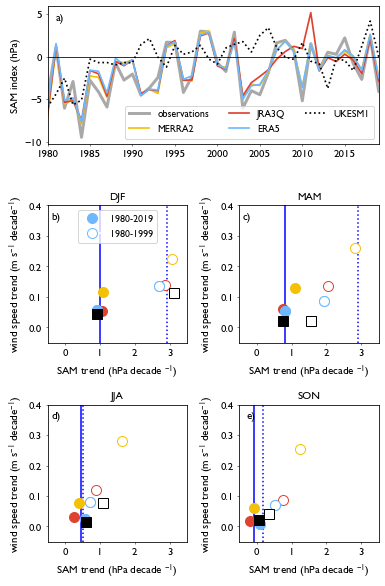

In [12]:
fact = 0.9
fig = plt.figure(figsize=(6.1*fact, 9.2*fact))
gs = fig.add_gridspec(3, 2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

axar = [ax2, ax3, ax4, ax5]
prods = ['MERRA', 'JRA3Q', 'ERA5', 'UKESMEM']
ss = ['DJF', 'MAM', 'JJA', 'SON']

ind = 0
for s in range(0, 4):

    ts = ss[s]
    ax = axar[ind]

    obst = SAM_trend.at[ts, 'obs']
    ax.axvline(obst, color='b')
    obst = SAM_trend80.at[ts, 'obs']
    ax.axvline(obst, color='b', linestyle=':')

    xa = []
    ya = []

    for i in range(0, 4):
        x = SAM_trend.at[ts, f'{prods[i]}']
        xs = SAM_sig.at[ts, f'{prods[i]}']
        y = wspd_trend.at[ts, f'{prods[i]}']
        ys = wspd_sig.at[ts, f'{prods[i]}']

        xa.append(x)
        ya.append(y)

        mkz = 'o'; ms = 10
        if prods[i] == 'UKESMEM':
            mkz = 's'; ms = 10; lab = 'UKESM'
        elif prods[i] == 'JRA3Q':
            lab = 'JRA'
        else:
            lab = prods[i]

        ax.plot(x, y, color=cd.prod[lab]['col'],
                marker=mkz, markersize=ms,
                markeredgecolor=cd.prod[lab]['col'], alpha=1)
        if lab == 'ERA5':
            ax.plot(x, y, color=cd.prod[lab]['col'],
                    marker=mkz, markersize=ms,
                    markeredgecolor=cd.prod[lab]['col'],
                    label='1980-2019', linewidth=0, alpha=1)

    for i in range(0, 4):
        x = SAM_trend80.at[ts, f'{prods[i]}']
        xs = SAM_sig80.at[ts, f'{prods[i]}']
        y = wspd_trend80.at[ts, f'{prods[i]}']
        ys = wspd_sig80.at[ts, f'{prods[i]}']

        mkz = 'o'; ms = 10
        if prods[i] == 'UKESMEM':
            mkz = 's'; ms = 10; lab = 'UKESM'
        elif prods[i] == 'JRA3Q':
            lab = 'JRA'
        else:
            lab = prods[i]

        xa.append(x)
        ya.append(y)

        ax.plot(x, y, color='w',
                marker=mkz, markersize=ms,
                markeredgecolor=cd.prod[lab]['col'], alpha=1)
        if lab == 'ERA5':
            ax.plot(x, y, color='w',
                    marker=mkz, markersize=ms,
                    markeredgecolor=cd.prod[lab]['col'],
                    label='1980-1999', alpha=1)

    ax.set_title(f'{ss[ind]}', fontproperties=gill_font)
    slope, intercept, r_value, p_value, std_err = linregress(xa, ya)
    print(f'{ss[ind]}, {r_value}, {p_value}')

    ax.set_xlim([-0.5, 3.5])
    ax.set_ylim([-0.05, 0.4])
    ax.set_xlabel('SAM trend (hPa decade $^{-1}$)', fontproperties=gill_font)
    ax.set_ylabel('wind speed trend (m s$^{-1}$ decade$^{-1}$)', fontproperties=gill_font)
    ax2.legend(loc='upper center', prop=gill_font_esmall)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(gill_font)

    ax.tick_params(axis='both', length=2, width=0.5, direction='out')
    ind += 1


prods2 = ['obs', 'MERRA', 'JRA3Q', 'ERA5', 'UKESMEM']
for prod in prods2:

    if prod == 'JRA3Q':
        lab = 'JRA'
    elif prod == 'UKESMEM':
        lab = 'UKESM'
    else:
        lab = prod

    mkz = 'o'; ms = 10; lw = 1.7; ls = '-'
    if prod == 'obs':
        mkz = '*'; ms = 20; lw = 3
    if prod == 'UKESMEM':
        mkz = 's'; ms = 10; ls = ':'; lab = 'UKESM'

    if lab == 'UKESM':
        w = xr.open_dataset('/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/UKESMEM/SAM.nc')
    else:
        w = xr.open_dataset(f'/gpfs/data/greenocean2/software/products/windsFromComponents/SAM/{lab}/SAM.nc')

    wmn = w.sel(time=(w['time.season'] == 'DJF')).resample(time='Y').mean()
    dt = pd.to_datetime(wmn.time)
    ax1.plot(dt.year, wmn.SAM, color=cd.prod[lab]['col'], linewidth=lw,
             label=cd.prod[lab]['fnam'], linestyle=ls)

    for label in ax1.get_xticklabels() + ax1.get_yticklabels():
        label.set_fontproperties(gill_font)


ax1.legend(ncol=3, loc='best', prop=gill_font_esmall)
ax1.tick_params(axis='both', length=2, width=0.5, direction='out')
ax1.set_xlim([1980, 2019])
ax1.axhline(y=0, color = 'k', linewidth = 0.8)
ax1.set_ylabel('SAM index (hPa)', fontproperties=gill_font)

fs = 11
ax1.text(0.025, 0.95, 'a)', transform=ax1.transAxes, fontsize=fs, va='top', ha='left', fontproperties=gill_font)
ax2.text(0.025, 0.95, 'b)', transform=ax2.transAxes, fontsize=fs, va='top', ha='left', fontproperties=gill_font)
ax3.text(0.025, 0.95, 'c)', transform=ax3.transAxes, fontsize=fs, va='top', ha='left', fontproperties=gill_font)
ax4.text(0.025, 0.95, 'd)', transform=ax4.transAxes, fontsize=fs, va='top', ha='left', fontproperties=gill_font)
ax5.text(0.05,  0.95, 'e)', transform=ax5.transAxes, fontsize=fs, va='top', ha='left', fontproperties=gill_font)

plt.tight_layout()
fig.savefig('./plts-gill/Fig-SAM.jpg', dpi=300, bbox_inches='tight')

import jpgtopdf as jp
jp.convert_jpg_to_pdf('./plts-gill/Fig-SAM.jpg', './plts-gill/fig5.pdf')

In [10]:
print('test done')

test done
